# **I. Model Development Introduction**

## 1. **What is a Model?**
* **Definition:** A model (or estimator) is a mathematical equation used to predict a value given one or more other values.
* **Mechanism:** It relates one or more **independent variables** (features/inputs) to a **dependent variable** (the output/target).
* **Example:** Using a car's `highway-mpg` (independent variable) to predict its `price` (dependent variable).

## 2. **The Importance of Data**
* **General Rule:** Usually, the more relevant data (features) you input into your model, the more accurate your predictions will be.
* **The "Pink Car" Example:** If you have two identical cars, but one is red and one is pink (which sells for less), **a model lacking `color` as an independent variable will inaccurately predict the exact same price for both.**

## 3. **Topics Covered in this Module**
* Simple and Multiple Linear Regression.
* Polynomial Regression and Pipelines.
* Model evaluation using visualization.
* R-squared and Mean Squared Error (MSE) for in-sample evaluation.
* Prediction, decision making, and determining a fair value for a used car.

---
# **II. Hồi quy Tuyến tính (Linear Regression)**

## 1. **Hồi quy Tuyến tính Đơn giản (Simple Linear Regression - SLR)**
* **Định nghĩa:** Phương pháp sử dụng **1 biến độc lập** ($x$) để dự đoán **1 biến phụ thuộc** ($y$).
* **Công thức toán học:** 
  $$\hat{y} = b_0 + b_1x$$
  * $\hat{y}$: Giá trị dự đoán (ước lượng).
  * $b_0$: Điểm giao cắt trục tung (Intercept).
  * $b_1$: Độ dốc (Slope).
* **Nhiễu (Noise):** Có một sự sai lệch nhỏ ngẫu nhiên cộng thêm vào các điểm dữ liệu thực tế so với đường hồi quy lý tưởng. Nếu giả định tuyến tính là đúng, sai số giữa giá trị thực tế và giá trị dự đoán chủ yếu đến từ nhiễu này.

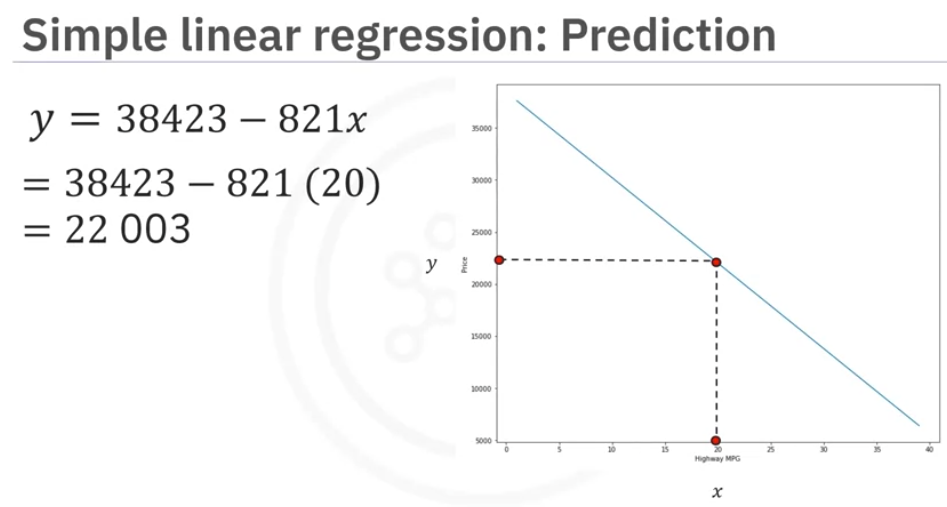
## 2. **Hồi quy Tuyến tính Bội (Multiple Linear Regression - MLR)**
* **Định nghĩa:** Sử dụng **nhiều biến độc lập** ($x_1, x_2, \dots, x_n$) để giải thích mối quan hệ với **1 biến phụ thuộc liên tục** ($y$).
* **Công thức toán học:**
  $$\hat{y} = b_0 + b_1x_1 + b_2x_2 + \dots + b_nx_n$$
  * $b_0$: Intercept (Giá trị của $\hat{y}$ khi tất cả các $x = 0$).
  * $b_1, b_2, \dots, b_n$: Các hệ số (Coefficients / Parameters) thể hiện trọng số tác động của từng biến $x$.
* **Trực quan hóa:** Nếu có 2 biến độc lập ($x_1, x_2$), dữ liệu có thể được ánh xạ trên một mặt phẳng tọa độ 2D, với $\hat{y}$ là chiều cao dọc theo trục thẳng đứng tương ứng.

## 3. **Triển khai mô hình trong Python (scikit-learn)**
* **Khởi tạo:** `lm = LinearRegression()`
* **Huấn luyện (Training):** Dùng `lm.fit(X, y)` để đưa các điểm dữ liệu vào máy học nhằm tìm ra các tham số lý tưởng ($b_0$, $b_1$,...).
* **Dự đoán (Prediction):** Dùng `lm.predict(X)` để xuất ra mảng kết quả $\hat{y}$ cho các mẫu dữ liệu chưa biết.
* **Trích xuất các tham số:** 
  * Lấy $b_0$: `lm.intercept_`
  * Lấy mảng các $b_1, b_2, \dots$: `lm.coef_`

In [4]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Tạo DataFrame giả lập dữ liệu xe
df = pd.DataFrame({
    'highway_mpg': [20, 25, 30, 35, 40],
    'engine_size': [130, 110, 90, 80, 70],
    'horsepower': [111, 100, 80, 75, 60],
    'price': [22000, 18000, 15000, 12000, 10000]
})

print("==== DỮ LIỆU HUẤN LUYỆN (TRAINING DATA) ====")
print(df)
print("\n")

# --- VÍ DỤ 1: SIMPLE LINEAR REGRESSION ---
print("==== 1. SIMPLE LINEAR REGRESSION (SLR) ====")
lm_slr = LinearRegression()

# Biến độc lập (X) phải là mảng 2 chiều (DataFrame)
X_slr = df[['highway_mpg']]
Y = df['price']

# Huấn luyện mô hình
lm_slr.fit(X_slr, Y)
b0_slr = lm_slr.intercept_
b1_slr = lm_slr.coef_[0]

print(f"Phương trình SLR: Giá xe (Price) = {b0_slr:.2f} + ({b1_slr:.2f}) * highway_mpg")
# Dự đoán với dữ liệu không nằm trong tập huấn luyện
print(f"Dự đoán giá cho xe có highway_mpg = 22: ${lm_slr.predict([[22]])[0]:.2f}")
print("\n")

# --- VÍ DỤ 2: MULTIPLE LINEAR REGRESSION ---
print("==== 2. MULTIPLE LINEAR REGRESSION (MLR) ====")
lm_mlr = LinearRegression()

# Lấy 3 biến độc lập để đưa vào Z
Z = df[['highway_mpg', 'engine_size', 'horsepower']]

# Huấn luyện mô hình với nhiều biến
lm_mlr.fit(Z, Y)
b0_mlr = lm_mlr.intercept_
b_coefs = lm_mlr.coef_

print(f"Intercept (b0): {b0_mlr:.2f}")
print(f"Coefficients (b1, b2, b3): {b_coefs}")
print(f"Phương trình MLR: Price = {b0_mlr:.2f} + ({b_coefs[0]:.2f}*highway_mpg) + ({b_coefs[1]:.2f}*engine_size) + ({b_coefs[2]:.2f}*horsepower)")

# Dự đoán một mẫu mới chứa cả 3 thuộc tính
sample_predict = lm_mlr.predict([[22, 120, 105]])
print(f"Dự đoán giá cho mẫu mới: ${sample_predict[0]:.2f}")

==== DỮ LIỆU HUẤN LUYỆN (TRAINING DATA) ====
   highway_mpg  engine_size  horsepower  price
0           20          130         111  22000
1           25          110         100  18000
2           30           90          80  15000
3           35           80          75  12000
4           40           70          60  10000


==== 1. SIMPLE LINEAR REGRESSION (SLR) ====
Phương trình SLR: Giá xe (Price) = 33400.00 + (-600.00) * highway_mpg
Dự đoán giá cho xe có highway_mpg = 22: $20200.00


==== 2. MULTIPLE LINEAR REGRESSION (MLR) ====
Intercept (b0): 20986.75
Coefficients (b1, b2, b3): [-393.15673289  157.72626932 -104.85651214]
Phương trình MLR: Price = 20986.75 + (-393.16*highway_mpg) + (157.73*engine_size) + (-104.86*horsepower)
Dự đoán giá cho mẫu mới: $20254.53


c:\env-related\Python314\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\env-related\Python314\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
